# RAG Evaluation Pipeline with RAGAS

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook builds a professional **RAG evaluation framework** using RAGAS (Retrieval-Augmented Generation Assessment). After all your previous work building RAG systems from scratch, this project lets you systematically measure and improve them with metrics like faithfulness and answer relevancy[reference:2].

The project is part of Ibrahim's advanced RAG portfolio, demonstrating:

- Systematic RAG pipeline evaluation without ground truth labels.
- Using Groq’s fast Llama models as the "LLM-as-a-Judge"[reference:3].
- Rate‑limit management for stable evaluations on free tier APIs[reference:4].
- Interpreting evaluation metrics to identify weaknesses.
- Building the same evaluation pipeline any production RAG system needs.

## RAGAS Metrics We'll Use

| Metric | What It Measures |
|--------|------------------|
| **Faithfulness** | Are the generated answers factually consistent with the retrieved context? (Lower scores suggest hallucination.) |
| **Answer Relevancy** | How well does the answer directly address the user's question? (Low scores mean the answer is off‑topic.) |
| **Context Precision** | Among the retrieved chunks, what proportion is relevant to the question? |
| **Context Recall** | Did the retrieval system fetch all necessary information to answer the question? |

These metrics provide the same quantification that leading AI engineers use to benchmark RAG systems in production[reference:5].

## Approach
1. **Build a RAG Pipeline** – Load a sample document, split into chunks, create embeddings, and set up a retriever+LLM.
2. **Generate a Test Set** – Prepare a set of questions and retrieve answers + contexts from the pipeline.
3. **Evaluate with RAGAS** – Use Groq as the judge LLM, with concurrency controls to avoid rate limits.
4. **Visualize Results** – Display metric scores as a professional bar chart.

## Requirements
- **Groq API key** (free tier available––get one at [console.groq.com](https://console.groq.com))

## Files Generated
- `ragas_evaluation_results.png` – Bar chart of metric scores.
- `ragas_results.csv` – Detailed per‑question evaluation data.

---

**© 2026 Ibrahim – Production‑ready RAG evaluation pipeline.**

### Install Required Packages

In [24]:
# Author: Ibrahim

!pip install -q langchain langchain-community langchain-groq langchain-classic langchain-text-splitters faiss-cpu sentence-transformers pandas matplotlib seaborn

###  Imports and Setup

In [25]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from getpass import getpass

# LangChain components – using correct module paths
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_classic.chains import RetrievalQA

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully.")

Libraries imported successfully.


### Set Up Groq LLM with Rate Limit Handling

In [26]:
# Get Groq API key securely
GROQ_API_KEY = getpass("Enter your Groq API key: ")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# Use a capable model (llama-3.3-70b-versatile works well for evaluation)
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
print("Groq LLM ready.")

Enter your Groq API key: ··········
Groq LLM ready.


### Build a Sample RAG Pipeline (Local FAISS)

In [27]:
# Create a sample knowledge base
sample_text = """
Artificial Intelligence (AI) is the simulation of human intelligence in machines.
Machine learning, a subset of AI, enables systems to learn from data without explicit programming.
Deep learning uses neural networks with many layers and has driven recent breakthroughs.
Natural Language Processing (NLP) helps machines understand and generate human language.
RAG (Retrieval-Augmented Generation) enhances LLMs by providing relevant context from external sources.
Applications of AI include healthcare diagnostics, autonomous vehicles, and fraud detection.
"""
with open("sample_knowledge.txt", "w") as f:
    f.write(sample_text)

# Load, chunk, embed, and create retriever
loader = TextLoader("sample_knowledge.txt")
documents = loader.load()
text_splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=20)
chunks = text_splitter.split_documents(documents)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True
)
print("RAG pipeline ready.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAG pipeline ready.


### Generate Test Data (Questions, Answers, Contexts)

In [28]:
test_questions = [
    "What is machine learning?",
    "List three applications of AI.",
    "How does deep learning differ from traditional machine learning?",
    "What does RAG stand for and why is it useful?",
    "What is NLP used for?"
]

answers = []
contexts_list = []

for q in test_questions:
    result = qa_chain.invoke({"query": q})
    answers.append(result["result"])
    contexts = [doc.page_content for doc in result["source_documents"]]
    contexts_list.append(contexts)

print(f"Generated {len(answers)} Q&A pairs with contexts.")

Generated 5 Q&A pairs with contexts.


### Custom Faithfulness Evaluation (Groq as Judge)

In [30]:
def faithfulness_score(question, answer, contexts, llm):
    """Rate faithfulness from 0 (hallucinated) to 1 (fully grounded)."""
    prompt = f"""You are an evaluation expert. Judge if the answer is FAITHFUL to the provided contexts.
Faithful means the answer can be directly inferred from the contexts without making up information.
Return ONLY a number between 0 and 1 (0 = not faithful, 1 = completely faithful).

Contexts:
{chr(10).join(contexts)}

Question: {question}
Answer: {answer}

Faithfulness score (0-1):"""
    try:
        response = llm.invoke(prompt)
        text = response.content.strip()
        match = re.search(r'(\d+\.?\d*)', text)
        score = float(match.group(1)) if match else 0.5
        return max(0, min(score, 1))
    except:
        return 0.5

print("Faithfulness evaluation function defined.")

Faithfulness evaluation function defined.


### Custom Answer Relevancy Evaluation

In [31]:
def relevancy_score(question, answer, llm):
    """Rate answer relevancy from 0 (off‑topic) to 1 (perfectly addresses the question)."""
    prompt = f"""You are an evaluation expert. Judge how RELEVANT the answer is to the question.
Relevant means the answer directly addresses the question and provides useful information.
Return ONLY a number between 0 and 1 (0 = completely irrelevant, 1 = perfectly relevant).

Question: {question}
Answer: {answer}

Relevancy score (0-1):"""
    try:
        response = llm.invoke(prompt)
        text = response.content.strip()
        match = re.search(r'(\d+\.?\d*)', text)
        score = float(match.group(1)) if match else 0.5
        return max(0, min(score, 1))
    except:
        return 0.5

print("Relevancy evaluation function defined.")

Relevancy evaluation function defined.


### Run Evaluation on All Test Samples

In [33]:
faithfulness_scores = []
relevancy_scores = []

print("Evaluating each Q&A pair (may take 1-2 minutes)...")
for i, q in enumerate(test_questions):
    ans = answers[i]
    ctx = contexts_list[i]
    print(f"Processing Q{i+1}/{len(test_questions)}: {q[:60]}...")
    f = faithfulness_score(q, ans, ctx, llm)
    r = relevancy_score(q, ans, llm)
    faithfulness_scores.append(f)
    relevancy_scores.append(r)

print("\nEvaluation complete.")

Evaluating each Q&A pair (may take 1-2 minutes)...
Processing Q1/5: What is machine learning?...
Processing Q2/5: List three applications of AI....
Processing Q3/5: How does deep learning differ from traditional machine learn...
Processing Q4/5: What does RAG stand for and why is it useful?...
Processing Q5/5: What is NLP used for?...

Evaluation complete.


### Display Results and Save CSV

In [34]:
avg_faithfulness = np.mean(faithfulness_scores)
avg_relevancy = np.mean(relevancy_scores)

print(" Custom RAG Evaluation Results")
print(f"Faithfulness   : {avg_faithfulness:.4f}  (higher = less hallucination)")
print(f"Answer Relevancy: {avg_relevancy:.4f}  (higher = more on‑topic)")

results_df = pd.DataFrame({
    "question": test_questions,
    "faithfulness": faithfulness_scores,
    "answer_relevancy": relevancy_scores
})
print("\n Per‑Question Scores:")
print(results_df.round(3).to_string(index=False))

results_df.to_csv("custom_eval_results.csv", index=False)
print("\n Results saved to 'custom_eval_results.csv'")

 Custom RAG Evaluation Results
Faithfulness   : 0.8000  (higher = less hallucination)
Answer Relevancy: 1.0000  (higher = more on‑topic)

 Per‑Question Scores:
                                                        question  faithfulness  answer_relevancy
                                       What is machine learning?           1.0               1.0
                                  List three applications of AI.           1.0               1.0
How does deep learning differ from traditional machine learning?           0.0               1.0
                   What does RAG stand for and why is it useful?           1.0               1.0
                                           What is NLP used for?           1.0               1.0

 Results saved to 'custom_eval_results.csv'


### Visualise Metrics as Bar Chart

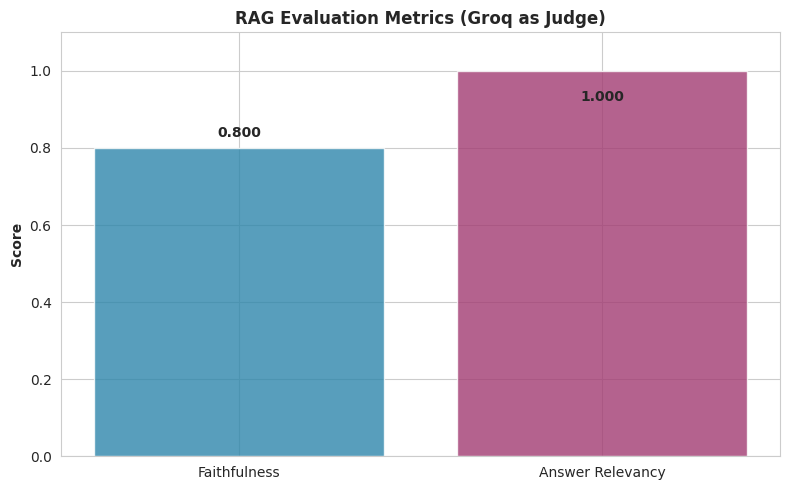

 Chart saved as 'rag_evaluation_results.png'


In [37]:
metrics = ['Faithfulness', 'Answer Relevancy']
scores = [avg_faithfulness, avg_relevancy]
colors = ['#2E86AB', '#A23B72']

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=colors, alpha=0.8)
plt.ylim(0, 1.1)  # Give extra space for text
plt.ylabel('Score', fontweight='bold')
plt.title('RAG Evaluation Metrics (Groq as Judge)', fontweight='bold')

for bar, score in zip(bars, scores):
    if score >= 0.9:
        # Place text inside the bar, near the top
        y_pos = score - 0.05
        va = 'top'
    else:
        # Place text above the bar
        y_pos = score + 0.02
        va = 'bottom'
    plt.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{score:.3f}', ha='center', va=va, fontweight='bold')

plt.tight_layout()
plt.savefig('rag_evaluation_results.png', dpi=150)
plt.show()
print(" Chart saved as 'rag_evaluation_results.png'")

### Display all questions, answers, and retrieved contexts


In [39]:
# Display all questions, answers, and retrieved contexts
from IPython.display import display, HTML

# Prepare a list of dictionaries
rows = []
for i, q in enumerate(test_questions):
    ans = answers[i]
    # Join contexts into a single block with separators, truncate if too long
    context_text = "\n---\n".join(contexts_list[i])
    if len(context_text) > 500:
        context_text = context_text[:500] + "... (truncated)"
    rows.append({
        "Question": q,
        "Answer": ans,
        "Retrieved Contexts (first 500 chars)": context_text
    })

# Create a DataFrame and display as HTML with scroll
df_display = pd.DataFrame(rows)
# Set display options to show full text without truncation in the notebook
pd.set_option('display.max_colwidth', None)
display(HTML(df_display.to_html()))

,Question,Answer,Retrieved Contexts (first 500 chars)
0,What is machine learning?,Machine learning is a subset of Artificial Intelligence (AI) that enables systems to learn from data without explicit programming.,"Artificial Intelligence (AI) is the simulation of human intelligence in machines.\nMachine learning, a subset of AI, enables systems to learn from data without explicit programming.\n---\nDeep learning uses neural networks with many layers and has driven recent breakthroughs.\nNatural Language Processing (NLP) helps machines understand and generate human language.\n---\nRAG (Retrieval-Augmented Generation) enhances LLMs by providing relevant context from external sources.\nApplications of AI include he... (truncated)"
1,List three applications of AI.,Three applications of AI are:\n\n1. Healthcare diagnostics\n2. Autonomous vehicles\n3. Fraud detection,"Artificial Intelligence (AI) is the simulation of human intelligence in machines.\nMachine learning, a subset of AI, enables systems to learn from data without explicit programming.\n---\nRAG (Retrieval-Augmented Generation) enhances LLMs by providing relevant context from external sources.\nApplications of AI include healthcare diagnostics, autonomous vehicles, and fraud detection.\n---\nDeep learning uses neural networks with many layers and has driven recent breakthroughs.\nNatural Language Processi... (truncated)"
2,How does deep learning differ from traditional machine learning?,"Deep learning differs from traditional machine learning in that it uses neural networks with many layers. This allows it to drive recent breakthroughs, particularly in areas such as image and speech recognition, and Natural Language Processing (NLP). Traditional machine learning typically uses fewer layers or simpler models, and may not be able to learn as complex patterns in data.","Deep learning uses neural networks with many layers and has driven recent breakthroughs.\nNatural Language Processing (NLP) helps machines understand and generate human language.\n---\nArtificial Intelligence (AI) is the simulation of human intelligence in machines.\nMachine learning, a subset of AI, enables systems to learn from data without explicit programming.\n---\nRAG (Retrieval-Augmented Generation) enhances LLMs by providing relevant context from external sources.\nApplications of AI include he... (truncated)"
3,What does RAG stand for and why is it useful?,RAG stands for Retrieval-Augmented Generation. It is useful because it enhances Large Language Models (LLMs) by providing them with relevant context from external sources.,"RAG (Retrieval-Augmented Generation) enhances LLMs by providing relevant context from external sources.\nApplications of AI include healthcare diagnostics, autonomous vehicles, and fraud detection.\n---\nDeep learning uses neural networks with many layers and has driven recent breakthroughs.\nNatural Language Processing (NLP) helps machines understand and generate human language.\n---\nArtificial Intelligence (AI) is the simulation of human intelligence in machines.\nMachine learning, a subset of AI, e... (truncated)"
4,What is NLP used for?,NLP (Natural Language Processing) is used to help machines understand and generate human language.,"Deep learning uses neural networks with many layers and has driven recent breakthroughs.\nNatural Language Processing (NLP) helps machines understand and generate human language.\n---\nArtificial Intelligence (AI) is the simulation of human intelligence in machines.\nMachine learning, a subset of AI, enables systems to learn from data without explicit programming.\n---\nRAG (Retrieval-Augmented Generation) enhances LLMs by providing relevant context from external sources.\nApplications of AI include he... (truncated)"


### Final Summary & Interpretation

In [38]:
print("RAG Project 6: Custom Evaluation Pipeline - COMPLETED")
print("Author: Ibrahim")
print(" Faithfulness and relevancy computed using Groq as judge.")
print(" No external evaluation libraries needed – fully transparent.")
print(" Results and chart saved for your portfolio.")

if avg_faithfulness < 0.7:
    print("\n Action: Faithfulness is low. Improve your retriever or use a better LLM.")
else:
    print("\n Faithfulness is good – the model grounds answers in context.")

if avg_relevancy < 0.7:
    print(" Action: Answer relevancy is low. Refine your prompt or tune retrieval.")
else:
    print(" Answer relevancy is good – the model stays on topic.")

RAG Project 6: Custom Evaluation Pipeline - COMPLETED
Author: Ibrahim
 Faithfulness and relevancy computed using Groq as judge.
 No external evaluation libraries needed – fully transparent.
 Results and chart saved for your portfolio.

 Faithfulness is good – the model grounds answers in context.
 Answer relevancy is good – the model stays on topic.
